In [1]:
! pip install devito

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN
from skimage.transform import resize
from sklearn.cluster import KMeans

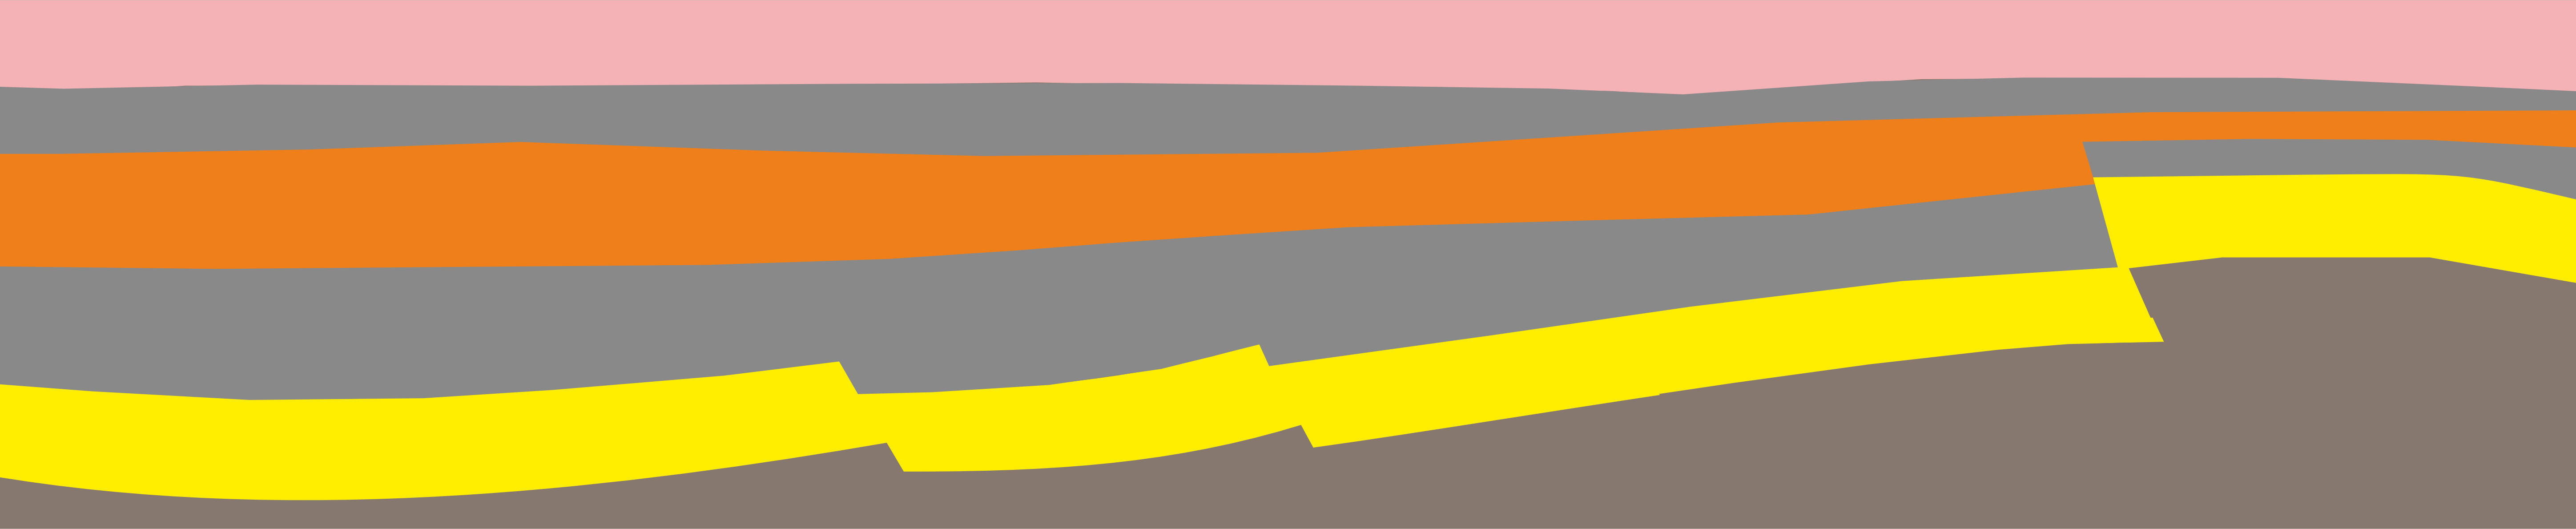

In [2]:
# Load an image
img2 = Image.open("strike_cross_sectionBEST_y_150.png")
#img2 = Image.open("actualStrikeFan.png")
#img = Image.open("overburdenCorel.png")
img = Image.open("overburdenNDeltaShallow.png")
img

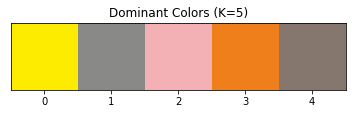

In [3]:
from sklearn.cluster import KMeans

# Step 1: Load the image
im = np.array(img)[..., :3]  # Keep only RGB channels (ignore alpha if present)

# Step 2: Prepare the data
X = im.reshape(-1, 3)  # Reshape to (height * width, 3)

# Step 3: Apply K-Means
n_clusters = 5  # Number of dominant colors to extract
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X)

# Step 4: Collect the colors (cluster centers)
colours = kmeans.cluster_centers_.astype(int)  # Get cluster centers

# Step 5: Visualize the colors
plt.imshow([colours / 255])  # Normalize to [0, 1] for display
plt.yticks([])
plt.title(f"Dominant Colors (K={n_clusters})")
plt.show()

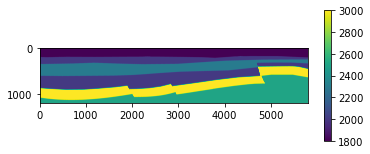

In [4]:
from scipy.spatial import cKDTree

kdtree = cKDTree(colours)
_, ix = kdtree.query(im)

plt.imshow(ix)

rocks = np.array([
    3000,
    2000,
    1800,
    2300,
    2500
])

overburden_vel = rocks[ix]

plt.imshow(overburden_vel)
plt.colorbar(shrink=0.6)
plt.show()

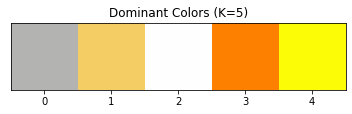

In [5]:
from sklearn.cluster import KMeans

# Step 1: Load the image
im2 = np.array(img2)[..., :3]  # Keep only RGB channels (ignore alpha if present)

# Step 2: Prepare the data
X2 = im2.reshape(-1, 3)  # Reshape to (height * width, 3)

# Step 3: Apply K-Means
n_clusters = 5  # Number of dominant colors to extract
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X2)

# Step 4: Collect the colors (cluster centers)
colours2 = kmeans.cluster_centers_.astype(int)  # Get cluster centers

# Step 5: Visualize the colors
plt.imshow([colours2 / 255])  # Normalize to [0, 1] for display
plt.yticks([])
plt.title(f"Dominant Colors (K={n_clusters})")
plt.show()

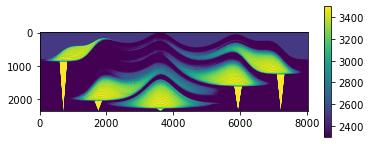

In [10]:
from scipy.spatial import cKDTree

kdtree = cKDTree(colours2)
_, ix2 = kdtree.query(im2)

plt.imshow(ix2)

# assign velocity to lithology
rocks2 = np.array([
    2300,
    3500,#1500
    2500,#3200
    3500,#3500
    3500#3500
])
fan_vel = rocks2[ix2]

plt.imshow(fan_vel)
plt.colorbar(shrink=0.6)
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

def build_model_with_image_overburden(fan_vel,
                                      overburden_vel,
                                      dz=4.0,
                                      dx=4.0,
                                      fan_thickness_m=100.0,
                                      fan_width_m=3200.0,
                                      overburden_thickness_m=500.0,
                                      fan_gap_top_m=50.0,
                                      fan_gap_bottom_m=50.0,
                                      gap_velocity=2700,#None
                                      bottom_gap_velocity=None,
                                      plot=True):
    """
    Embeds a submarine fan between image-derived overburden and underlying gap.

    Parameters:
        - fan_vel: 2D array of fan velocity (in m/s)
        - overburden_vel: 2D array of overburden velocity (in m/s)
        - dz, dx: spatial sampling in meters
        - fan_thickness_m: fan height (m)
        - fan_width_m: fan width (m)
        - overburden_thickness_m: overburden thickness (m)
        - fan_gap_top_m: vertical gap above the fan (m)
        - fan_gap_bottom_m: vertical gap below the fan (m)
        - gap_velocity: optional velocity for top gap
        - bottom_gap_velocity: optional velocity for bottom gap
        - plot: display final model

    Returns:
        - model_vel: full 2D velocity model (in m/s)
    """
    # Original dimensions
    nz_fan, nx_fan = fan_vel.shape
    nz_ob, nx_ob = overburden_vel.shape

    # Target dimensions
    fan_thick_samples = int(fan_thickness_m / dz)
    fan_width_samples = int(fan_width_m / dx)
    gap_top_samples = int(fan_gap_top_m / dz)
    gap_bottom_samples = int(fan_gap_bottom_m / dz)
    ob_thick_samples = int(overburden_thickness_m / dz)

    # --- Resample fan and overburden ---
    fan_resized = zoom(fan_vel, (fan_thick_samples / nz_fan, fan_width_samples / nx_fan), order=1)
    overburden_resized = zoom(overburden_vel, (ob_thick_samples / nz_ob, fan_width_samples / nx_ob), order=1)

    # --- Gaps ---
    if gap_velocity is None:
        gap_velocity = overburden_resized[-1, :].mean()
    if bottom_gap_velocity is None:
        bottom_gap_velocity = fan_resized[-1, :].mean()

    gap_top = np.ones((gap_top_samples, fan_width_samples)) * gap_velocity
    gap_bottom = np.ones((gap_bottom_samples, fan_width_samples)) * bottom_gap_velocity

    # --- Stack: Overburden → Top Gap → Fan → Bottom Gap ---
    model_vel = np.vstack([
        overburden_resized,
        gap_top,
        fan_resized,
        gap_bottom
    ])

    # --- Convert to km/s ---
    model_vel /= 1000.0

    # --- Plotting ---
    if plot:
        extent = [0, fan_width_samples * dx, model_vel.shape[0] * dz, 0]
        plt.figure(figsize=(12, 6))
        plt.imshow((model_vel*1000), cmap='viridis', aspect='auto', extent=extent)
        plt.colorbar(label='Velocity (m/s)')
        plt.title("Velocity Model: Overburden + Gaps + Fan")
        plt.xlabel("Distance (m)")
        plt.ylabel("Depth (m)")
        plt.grid(False)
        plt.show()

    return model_vel


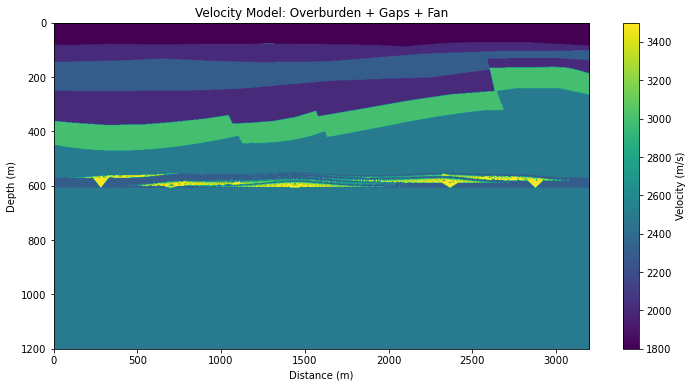

In [15]:
model_vel = build_model_with_image_overburden(
    fan_vel=fan_vel,
    overburden_vel=overburden_vel,
    dz=2.0,
    dx=2.0,
    fan_thickness_m=60.0,
    fan_width_m=3200.0,
    overburden_thickness_m=500.0,
    fan_gap_top_m=50.0,
    fan_gap_bottom_m=590.0,
    gap_velocity=2500,
    bottom_gap_velocity=2500,
    plot=True
)


In [13]:
model_vel.shape

(600, 1600)

In [10]:
%matplotlib inline
import numpy as np

from devito import Operator,Eq,solve,Grid,SparseFunction,norm
from devito import TimeFunction,Function
from devito import gaussian_smooth
from devito import mmax

from devito.logger import info

from examples.seismic import Model
from examples.seismic import plot_velocity,plot_shotrecord
from examples.seismic import Receiver
from examples.seismic import PointSource
from examples.seismic import plot_image,AcquisitionGeometry
from examples.seismic import TimeAxis

from examples.seismic.self_adjoint import (setup_w_over_q)
from examples.seismic.acoustic import AcousticWaveSolver

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.ticker as plticker

from devito import configuration
configuration['log-level'] = 'WARNING'

In [12]:
import numpy as np
from devito import gaussian_smooth
from examples.seismic import Model
from examples.seismic.self_adjoint import setup_w_over_q

# Spatial domain
nx, nz = 1600, 600
dx, dz = 2.0, 2.0
shape = (nx, nz)
spacing = (dx, dz)
origin = (0., 0.)
nbl = 50
space_order = 8
dtype = np.float32


fpeak = 0.050 # Source peak frequency is 25Hz (0.025 kHz)
t0w = 1.0 / fpeak
omega = 2.0 * np.pi * fpeak
qmin = 0.1
qmax = 100000
npad=50
dtype = np.float32

nshots = 41 #21
nreceivers = 801# 101
t0 = 0.
tn = 800.  # Simulation last 1 second (1000 ms)
#tn = int((2 * (nz * dz)) / 2000 * 1000)  # ms
print(tn)
filter_sigma = (6, 6)

# Build the true velocity model
#vp_model = vp_model_shallow
#vp_model = vp_model_deep
vp_model = model_vel


# Damping boundary setup
init_damp = lambda func, nbl: setup_w_over_q(func, omega, qmin, qmax, nbl, sigma=0)

model = Model(vp=vp_model.T, origin=origin, spacing=spacing,
              shape=shape, space_order=space_order, bcs=init_damp,
              nbl=nbl, dtype=dtype)

model0 = Model(vp=vp_model.T, origin=origin, spacing=spacing,
               shape=shape, space_order=space_order, bcs=init_damp,
               nbl=nbl, dtype=dtype)

dt = model.critical_dt
s = model.grid.stepping_dim.spacing
time_range = TimeAxis(start=t0, stop=tn, step=dt)
nt=time_range.num


800.0


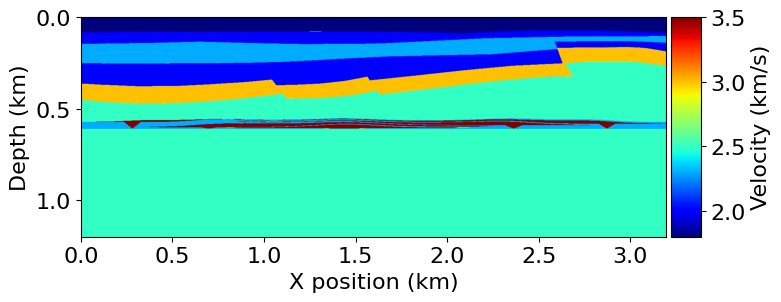

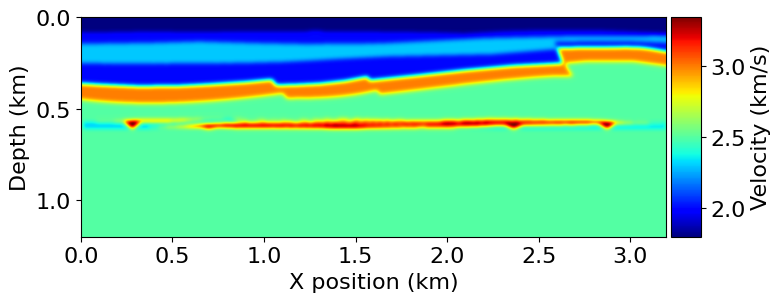

In [13]:
#NBVAL_IGNORE_OUTPUT
# Create initial model and smooth the boundaries
gaussian_smooth(model0.vp, sigma=filter_sigma)

# Plot the true and initial model
plot_velocity(model)
plot_velocity(model0)

In [14]:
# First, position source centrally in all dimensions, then set depth
src_coordinates = np.empty((1, 2))
src_coordinates[0, :] = np.array(model.domain_size) * .5
src_coordinates[0, -1] = 10.

# Define acquisition geometry: receivers

# Initialize receivers for synthetic and imaging data
rec_coordinates = np.empty((nreceivers, 2))
rec_coordinates[:, 0] = np.linspace(0, model.domain_size[0], num=nreceivers)
rec_coordinates[:, 1] = 10.

# Geometry
geometry = AcquisitionGeometry(model, rec_coordinates, src_coordinates, t0, tn, f0=fpeak, src_type='Ricker')

solver = AcousticWaveSolver(model, geometry, space_order=8)

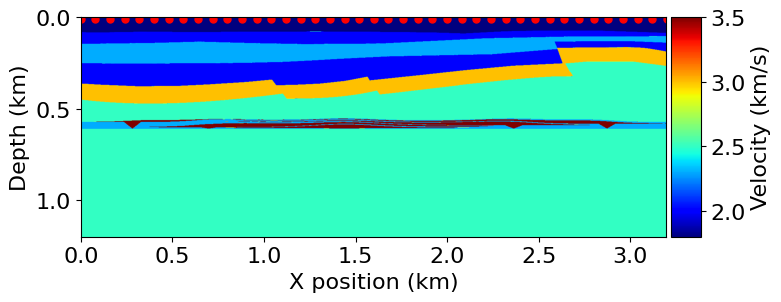

In [15]:
source_locations = np.empty((nshots, 2), dtype=dtype)
source_locations[:, 0] = np.linspace(0., 3200, num=nshots)
source_locations[:, 1] = 10 # Depth is 30m


plot_velocity(model, source=source_locations)

In [16]:
def lsrtm_gradient(dm):

    residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)

    d_obs = Receiver(name='d_obs', grid=model.grid,time_range=geometry.time_axis,
                         coordinates=geometry.rec_positions)

    d_syn = Receiver(name='d_syn', grid=model.grid,time_range=geometry.time_axis,
                         coordinates=geometry.rec_positions)

    grad_full = Function(name='grad_full', grid=model.grid)

    grad_illum = Function(name='grad_illum', grid=model.grid)

    src_illum = Function (name ="src_illum", grid = model.grid)

    # Using devito's reference of virtual source
    dm_true =  (solver.model.vp.data**(-2) - model0.vp.data**(-2))

    objective = 0.
    u0 = None
    for i in range(nshots):

        #Observed Data using Born's operator
        geometry.src_positions[0, :] = source_locations[i, :]

        _, u0, _ = solver.forward(vp=model0.vp, save=True, u=u0)

        _, _, _,_ = solver.jacobian(dm_true, vp=model0.vp, rec = d_obs)

        # Inject noise into the observed data: added by IB
        #noise_std = 0.100  # tweak this as needed
        #noise = np.random.normal(0, noise_std, size=d_obs.data.shape)
        #d_obs.data[:] = d_obs.data[:] + noise

        #Calculated Data using Born's operator
        solver.jacobian(dm, vp=model0.vp, rec = d_syn)

        residual.data[:] = d_syn.data[:]- d_obs.data[:]

        grad_shot,_ = solver.gradient(rec=residual, u=u0, vp=model0.vp)

        src_illum_upd =  Eq(src_illum, src_illum + u0**2)
        op_src = Operator([src_illum_upd])
        op_src.apply()

        grad_sum = Eq(grad_full, grad_full  + grad_shot)
        op_grad = Operator([grad_sum])
        op_grad.apply()

        objective += .5*norm(residual)**2

    grad_f = Eq(grad_illum, grad_full/(src_illum+10**-9))
    op_gradf = Operator([grad_f])
    op_gradf.apply()

    return objective,grad_illum,d_obs,d_syn

In [17]:
def get_alfa(grad_iter,image_iter,niter_lsrtm):


    term1 = np.dot(image_iter.reshape(-1), image_iter.reshape(-1))

    term2 = np.dot(image_iter.reshape(-1), grad_iter.reshape(-1))

    term3 = np.dot(grad_iter.reshape(-1), grad_iter.reshape(-1))

    if niter_lsrtm == 0:

        alfa = .05 / mmax(grad_full)

    else:
        abb1 = term1 / term2

        abb2 = term2 / term3

        abb3 = abb2 / abb1

        if abb3 > 0 and abb3 < 1:
            alfa = abb2
        else:
            alfa = abb1

    return alfa

In [ ]:
#NBVAL_IGNORE_OUTPUT
image_up_dev = np.zeros((model0.vp.shape[0], model0.vp.shape[1]),dtype)

image = np.zeros((model0.vp.shape[0], model0.vp.shape[1]))

nrec=801 # 101
niter= 15 #20 # number of iterations of the LSRTM
history = np.zeros((niter, 1)) #objective function

image_prev = np.zeros((model0.vp.shape[0],model0.vp.shape[1]))

grad_prev  = np.zeros((model0.vp.shape[0],model0.vp.shape[1]))

yk  = np.zeros((model0.vp.shape[0],model0.vp.shape[1]))

sk = np.zeros((model0.vp.shape[0],model0.vp.shape[1]))

for k in range(niter) :

    dm =  image_up_dev # Reflectivity for Calculated data via Born
    #dm = image_up_dev.astype(np.float32) # ✅ Ensure correct dtype for dm

    print('LSRTM Iteration',k+1)

    objective,grad_full,d_obs,d_syn = lsrtm_gradient(dm)

    history[k] = objective


    yk = grad_full.data - grad_prev

    sk = image_up_dev - image_prev

    alfa = get_alfa(yk,sk,k)
    #alfa = get_alfa(yk, sk, k, max_step=0.01)

    grad_prev = grad_full.data

    image_prev = image_up_dev

    image_up_dev = image_up_dev - alfa*grad_full.data

    if k == 0: # Saving the first migration using Born operator.

        image = image_up_dev

# ================================
# 📊 Global Evaluation (Full Model)
# ================================
slices = tuple(slice(model.nbl, -model.nbl) for _ in range(2))
lsrtm = image_up_dev[slices]
dm_true = (solver.model.vp.data**(-2) - model0.vp.data**(-2))[slices]

error = lsrtm - dm_true
mse = np.mean(error**2)
snr = 10 * np.log10(np.sum(dm_true**2) / np.sum(error**2))

from scipy.stats import pearsonr
corr, _ = pearsonr(lsrtm.flatten(), dm_true.flatten())

print("\n✅ LSRTM Evaluation (Full Model):")
print(f"  MSE:  {mse:.4e}")
print(f"  SNR:  {snr:.2f} dB")
print(f"  Corr: {corr:.3f}")

# =========================================
# 📍 Regional Evaluation (600–800 m Depth)
# =========================================
dz = model.spacing[1]  # vertical spacing (dz)
depth_min, depth_max = 850, 950  # meters

z0 = int(depth_min / dz) - model.nbl
z1 = int(depth_max / dz) - model.nbl

# Bounds check
if 0 <= z0 < z1 <= lsrtm.shape[1]:
    lsrtm_roi = lsrtm[:, z0:z1]
    dm_true_roi = dm_true[:, z0:z1]

    error_roi = lsrtm_roi - dm_true_roi
    mse_roi = np.mean(error_roi**2)
    snr_roi = 10 * np.log10(np.sum(dm_true_roi**2) / np.sum(error_roi**2))
    corr_roi, _ = pearsonr(lsrtm_roi.flatten(), dm_true_roi.flatten())

    print("\n📌 LSRTM Evaluation (600–800 m Depth):")
    print(f"  MSE:  {mse_roi:.4e}")
    print(f"  SNR:  {snr_roi:.2f} dB")
    print(f"  Corr: {corr_roi:.3f}")
else:
    print("\n⚠️  Depth range for regional evaluation is out of bounds.")

LSRTM Iteration 1


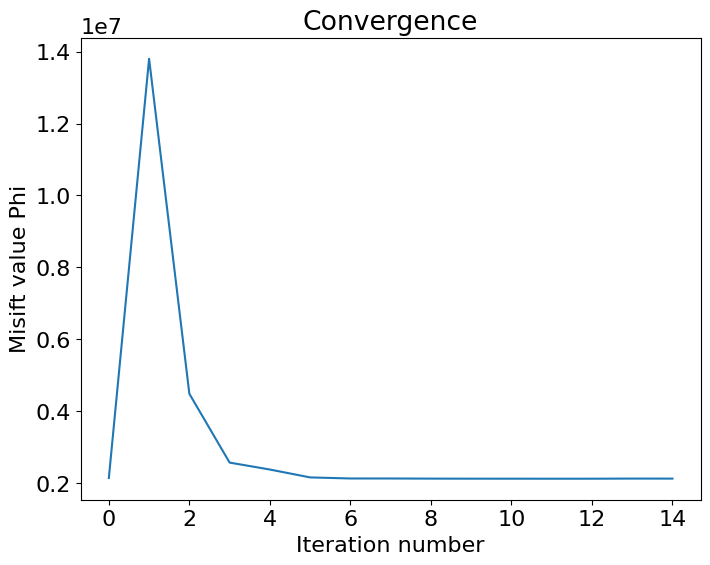

In [ ]:
#NBVAL_SKIP
plt.figure()
plt.plot(history)
plt.xlabel('Iteration number')
plt.ylabel('Misift value Phi')
plt.title('Convergence')
plt.show()

In [ ]:
history

array([[ 2138677.5 ],
       [13803683.  ],
       [ 4482752.5 ],
       [ 2568165.25],
       [ 2375124.5 ],
       [ 2155755.75],
       [ 2126261.  ],
       [ 2125848.5 ],
       [ 2122263.25],
       [ 2120618.  ],
       [ 2120365.  ],
       [ 2119351.25],
       [ 2119893.  ],
       [ 2123441.  ],
       [ 2122423.75]])

In [ ]:
def plot_image(data, vmin=None, vmax=None, colorbar=True, cmap="gray"):
    """
    Plot image data, such as RTM images or FWI gradients.

    Parameters
    ----------
    data : ndarray
        Image data to plot.
    cmap : str
        Choice of colormap. Defaults to gray scale for images as a
        seismic convention.
    """
    domain_size = 1.e-3 * np.array(model.domain_size)
    extent = [model.origin[0], model.origin[0] + domain_size[0],
              model.origin[1] + domain_size[1], model.origin[1]]
    plot = plt.imshow(np.transpose(data),
                      vmin=-.05,
                      vmax=.05,
                      cmap=cmap,extent=extent)

    plt.xlabel('X position (km)')
    plt.ylabel('Depth (km)')

    # Create aligned colorbar on the right
    if colorbar:
        ax = plt.gca()
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(plot, cax=cax)
    plt.show()

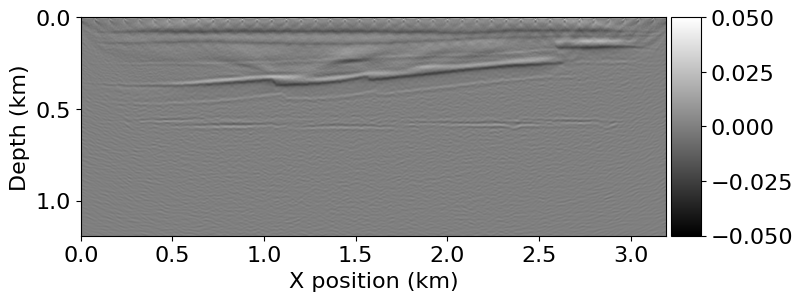

In [ ]:
#NBVAL_IGNORE_OUTPUT
slices=tuple(slice(model.nbl,-model.nbl) for _ in range(2))
rtm = image[slices]
plot_image(np.diff(rtm, axis=1))

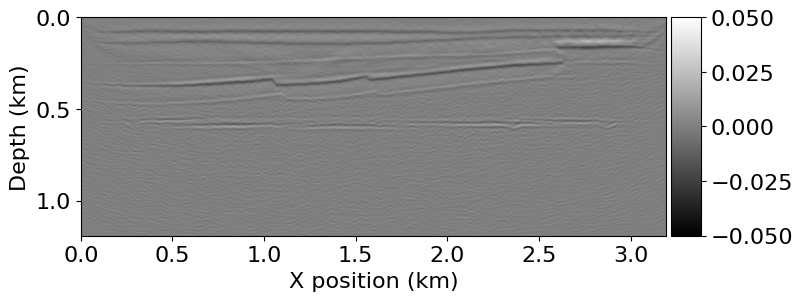

In [ ]:
#NBVAL_SKIP
slices=tuple(slice(model.nbl,-model.nbl) for _ in range(2))
lsrtm = image_up_dev[slices]
plot_image(np.diff(lsrtm, axis=1))

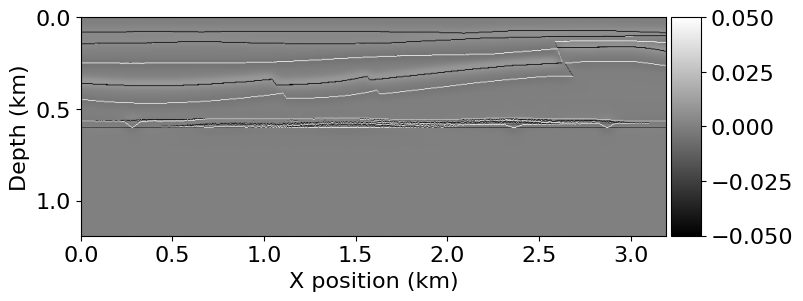

In [ ]:
#NBVAL_IGNORE_OUTPUT
slices=tuple(slice(model.nbl,-model.nbl) for _ in range(2))
dm_true = (solver.model.vp.data**(-2) - model0.vp.data**(-2))[slices]
plot_image(np.diff(dm_true, axis=1))

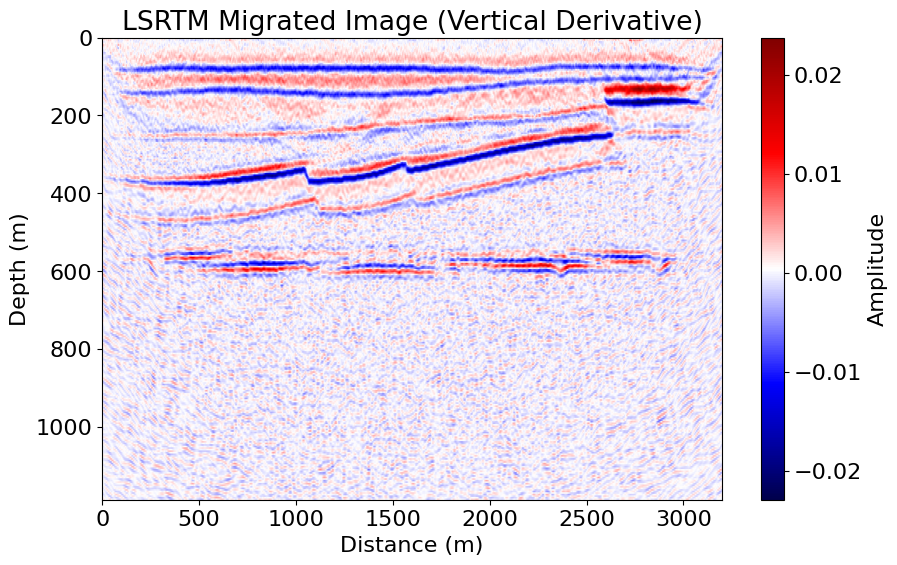

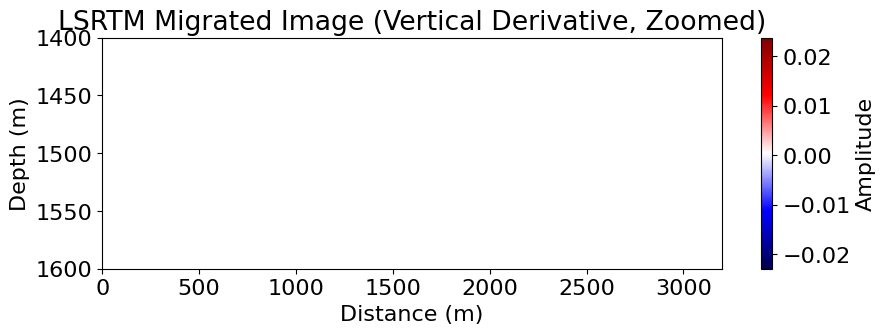

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img = np.diff(lsrtm, axis=1)  # vertical (depth) derivative

# Get dimensions and spacing from model
nx, nz = img.shape
dx, dz = model.spacing  # (x, z) spacing in meters

# Define plot extent: [xmin, xmax, zmax, zmin]
extent = [0, nx*dx, (nz-1)*dz, 0]  # NOTE: diff() reduces nz by 1

# --- Full Depth Plot ---
plt.figure(figsize=(10, 6))
plt.imshow(img.T, cmap='seismic', aspect='auto', extent=extent)
plt.colorbar(label='Amplitude')
plt.title('LSRTM Migrated Image (Vertical Derivative)')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.grid(False)
#plt.savefig('rtm_vertical_derivative_fullF30L2T1000b.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Zoomed Depth Plot ---
plt.figure(figsize=(10, 3))
plt.imshow(img.T, cmap='seismic', aspect='auto', extent=extent)
plt.colorbar(label='Amplitude')
plt.title('LSRTM Migrated Image (Vertical Derivative, Zoomed)')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.ylim(1600, 1400)  # Show only depth range between 1000 and 1200 m
plt.grid(False)
#plt.savefig('rtm_vertical_derivative_zoomedF30L2T1000b.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
np.save("lsrtm_imageStkMulNOF50D12KUrealND.npy", lsrtm)
np.save("rtm_imageStkMulNOF50D12KUrealND.npy", rtm)
np.save("dmtrue_imageStkMulNOF50U12KDrealND.npy", dm_true)